# 🎓 Student Dropout Prediction — Full Training Pipeline

Dataset: **Predict Students' Dropout and Academic Success** (UCI-style)
Target classes: `Dropout`, `Enrolled`, `Graduate`

Workflow in this notebook:
1. Load & inspect data
2. EDA
3. Preprocessing (encode target, train/test split, scaling)
4. Compare baseline models
5. Hyperparameter tuning on the best model
6. Evaluate on the test set
7. Save model + scaler + label encoder
8. Zip and download everything so you can use it in VS Code

> Before running: upload `students_dropout_academic_success.csv` to the Colab file browser (left sidebar → Files → upload) so it sits at `/content/students_dropout_academic_success.csv`.


In [1]:
# 1. Install/confirm libraries (xgboost is not always preinstalled)
!pip install -q xgboost joblib


In [2]:
# 2. Imports
import os
import json
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier

sns.set_style("whitegrid")
%matplotlib inline


In [3]:
# 3. Load the dataset
DATA_PATH = "/content/students_dropout_academic_success.csv"

# sep=None + engine='python' auto-detects the delimiter (comma, semicolon, or tab)
df = pd.read_csv(DATA_PATH, sep=None, engine="python")
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()


Shape: (4424, 37)

Columns:
 ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', '

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Exploratory Data Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

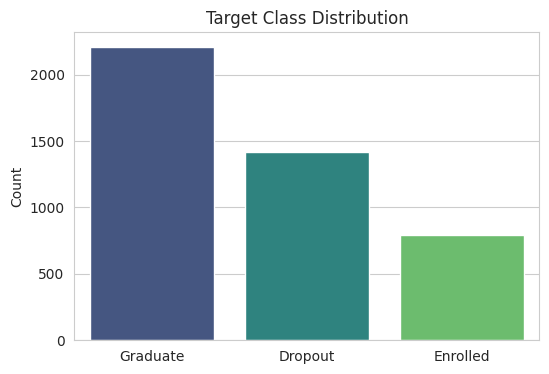

In [4]:
df.info()
print("\nTotal missing values:", df.isnull().sum().sum())
print("\nTarget distribution:\n", df["target"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target", order=df["target"].value_counts().index, palette="viridis")
plt.title("Target Class Distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.show()


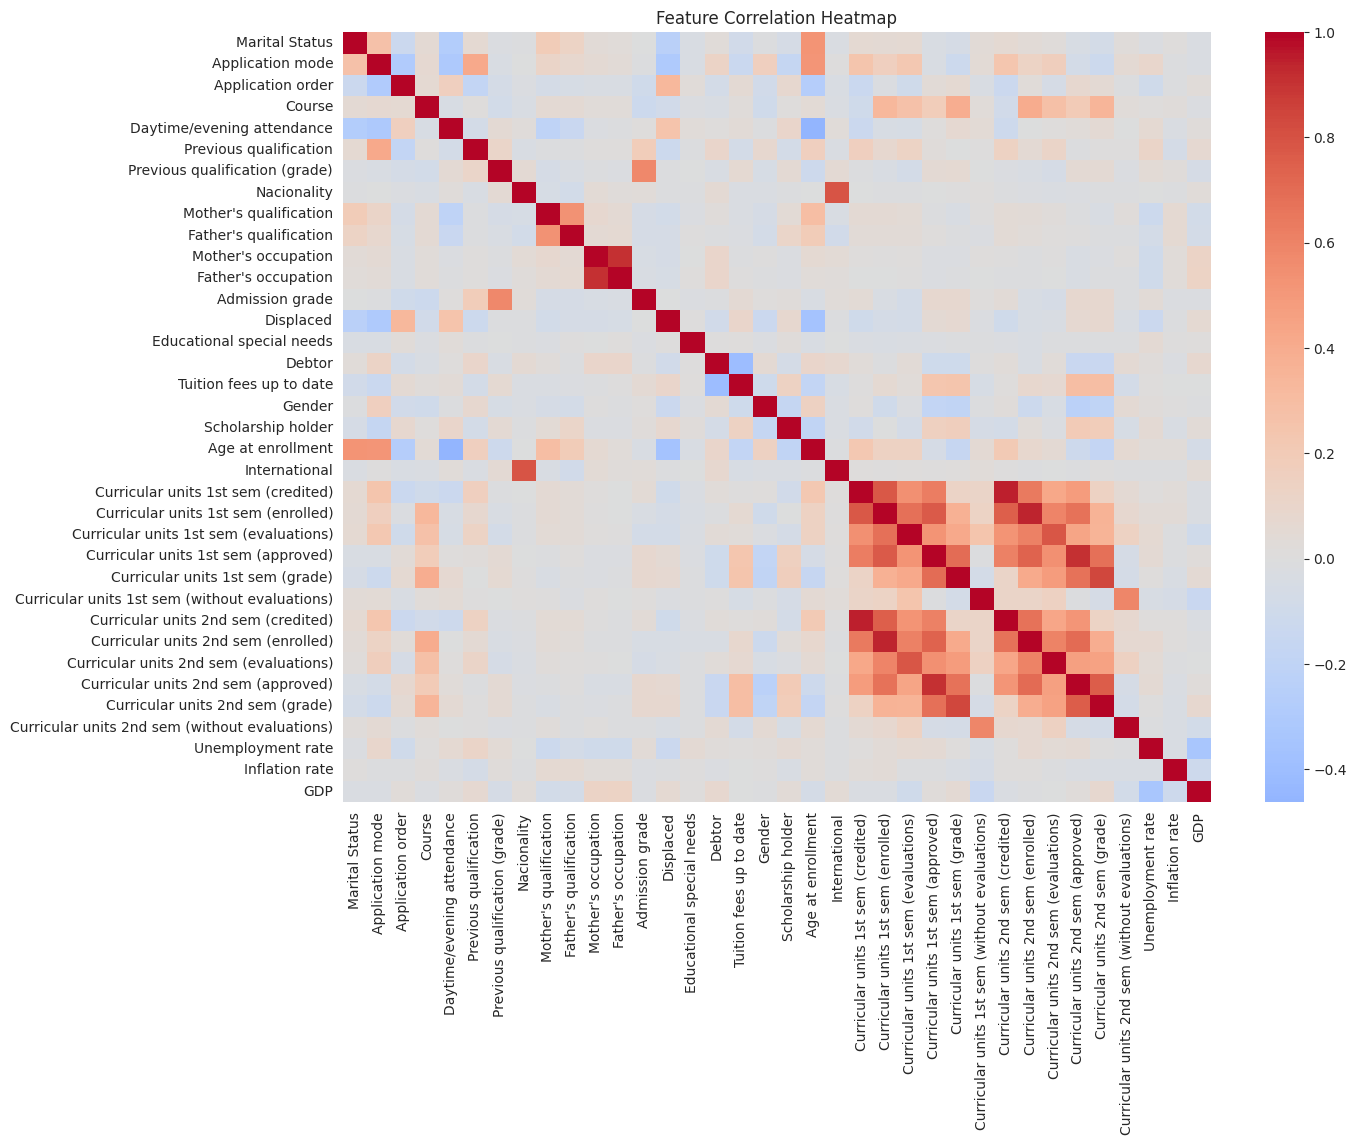

In [5]:
# Quick look at correlation of numeric features with each other (helps spot redundancy)
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


## Preprocessing

In [6]:
# Drop exact duplicate rows, drop any rows with missing values (dataset is normally clean)
df = df.drop_duplicates()
df = df.dropna()

# Encode the target (Dropout / Enrolled / Graduate) into integers
le_target = LabelEncoder()
df["target_encoded"] = le_target.fit_transform(df["target"])

print("Target class mapping:")
for cls, code_val in zip(le_target.classes_, le_target.transform(le_target.classes_)):
    print(f"  {cls} -> {code_val}")

X = df.drop(columns=["target", "target_encoded"])
y = df["target_encoded"]

feature_columns = X.columns.tolist()
print("\nNumber of features:", len(feature_columns))


Target class mapping:
  Dropout -> 0
  Enrolled -> 1
  Graduate -> 2

Number of features: 36


In [7]:
# Train/test split (stratified so class balance is preserved) + scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (3539, 36)  Test shape: (885, 36)


## Baseline model comparison (5-fold CV)

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results[name] = scores.mean()
    print(f"{name:20s}: {scores.mean():.4f}  (+/- {scores.std():.4f})")

best_model_name = max(cv_results, key=cv_results.get)
print("\nBest baseline model:", best_model_name)


Logistic Regression : 0.7660  (+/- 0.0139)
Random Forest       : 0.7723  (+/- 0.0117)
Gradient Boosting   : 0.7728  (+/- 0.0061)
XGBoost             : 0.7731  (+/- 0.0115)

Best baseline model: XGBoost


## Hyperparameter tuning on the best model

In [9]:
param_grids = {
    "Random Forest": {
        "n_estimators": [200, 300, 400],
        "max_depth": [10, 15, None],
        "min_samples_split": [2, 5],
    },
    "Gradient Boosting": {
        "n_estimators": [150, 250],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
    },
    "XGBoost": {
        "n_estimators": [200, 300],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.05, 0.1],
    },
}

base_model = models[best_model_name]

if best_model_name in param_grids:
    grid = GridSearchCV(
        base_model, param_grids[best_model_name],
        cv=3, scoring="accuracy", n_jobs=-1, verbose=1,
    )
    grid.fit(X_train_scaled, y_train)
    final_model = grid.best_estimator_
    print("Best params:", grid.best_params_)
else:
    final_model = base_model
    final_model.fit(X_train_scaled, y_train)

print("\nFinal model:", final_model)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}

Final model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


## Evaluation on the held-out test set

Test Accuracy: 0.7706214689265537
Weighted F1 Score: 0.7613731508036932

Classification Report:

              precision    recall  f1-score   support

     Dropout       0.81      0.73      0.77       284
    Enrolled       0.56      0.43      0.48       159
    Graduate       0.80      0.92      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



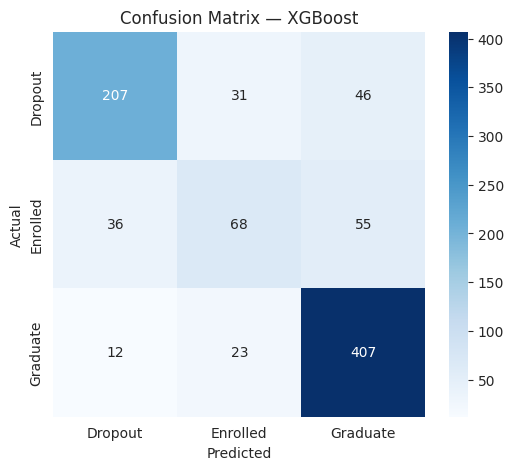

In [10]:
y_pred = final_model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le_target.classes_, yticklabels=le_target.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()


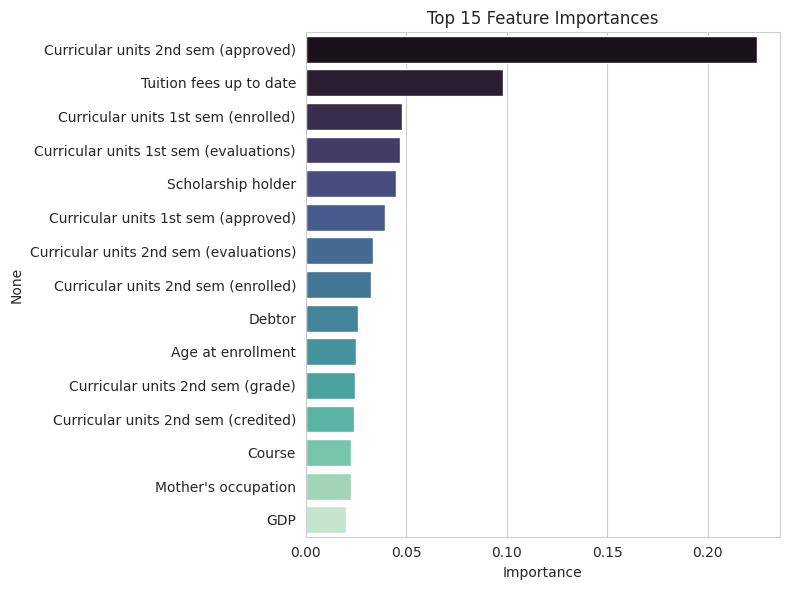

In [11]:
if hasattr(final_model, "feature_importances_"):
    importances = pd.Series(final_model.feature_importances_, index=feature_columns)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, palette="mako")
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Selected model does not expose feature_importances_")


## Save the model, scaler, encoder, and metadata

In [12]:
ARTIFACT_DIR = "/content/model_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

import joblib
joblib.dump(final_model, f"{ARTIFACT_DIR}/dropout_model.joblib")
joblib.dump(scaler, f"{ARTIFACT_DIR}/scaler.joblib")
joblib.dump(le_target, f"{ARTIFACT_DIR}/label_encoder.joblib")

metadata = {
    "model_name": best_model_name,
    "feature_columns": feature_columns,
    "target_classes": le_target.classes_.tolist(),
    "test_accuracy": float(accuracy_score(y_test, y_pred)),
    "test_f1_weighted": float(f1_score(y_test, y_pred, average="weighted")),
}
with open(f"{ARTIFACT_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved files:", os.listdir(ARTIFACT_DIR))


Saved files: ['metadata.json', 'label_encoder.joblib', 'dropout_model.joblib', 'scaler.joblib']


## Zip everything and download to your machine

In [13]:
from google.colab import files

shutil.make_archive("/content/model_artifacts", "zip", "/content/model_artifacts")
files.download("/content/model_artifacts.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Using the model in VS Code

1. Unzip `model_artifacts.zip` into your project folder. You should see:
   `dropout_model.joblib`, `scaler.joblib`, `label_encoder.joblib`, `metadata.json`.
2. In VS Code, create a virtual environment and install dependencies:

```bash
python -m venv venv
venv\Scripts\activate        # Windows
source venv/bin/activate      # macOS/Linux

pip install scikit-learn pandas numpy joblib xgboost
```

3. Create `predict.py` with the script below, in the same folder as the artifacts (or update `ARTIFACT_DIR`):

```python
import json
import joblib
import pandas as pd

ARTIFACT_DIR = "model_artifacts"

model = joblib.load(f"{ARTIFACT_DIR}/dropout_model.joblib")
scaler = joblib.load(f"{ARTIFACT_DIR}/scaler.joblib")
label_encoder = joblib.load(f"{ARTIFACT_DIR}/label_encoder.joblib")

with open(f"{ARTIFACT_DIR}/metadata.json") as f:
    metadata = json.load(f)

FEATURE_COLUMNS = metadata["feature_columns"]


def predict_student(student: dict):
    """student must contain every key listed in FEATURE_COLUMNS."""
    row = pd.DataFrame([student])[FEATURE_COLUMNS]
    row_scaled = scaler.transform(row)
    pred = model.predict(row_scaled)[0]
    label = label_encoder.inverse_transform([pred])[0]
    proba = None
    if hasattr(model, "predict_proba"):
        proba = dict(zip(label_encoder.classes_, model.predict_proba(row_scaled)[0]))
    return label, proba


if __name__ == "__main__":
    print("Expected features:", FEATURE_COLUMNS)

    # Replace with a real student's data — every key in FEATURE_COLUMNS is required
    sample = {col: 0 for col in FEATURE_COLUMNS}

    label, probabilities = predict_student(sample)
    print("Prediction:", label)
    print("Probabilities:", probabilities)
```

4. Run it:

```bash
python predict.py
```

That's it — same model, same preprocessing, running locally in VS Code.
